In [6]:
import math
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import os
import time
from tqdm.auto import tqdm

from shapenet_dataset import ShapeNetDataset

# autoreload py
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data Loading & Visualization

In [7]:
# pointcloud visualizer
def plot_pointclouds(pc_list):
    n = len(pc_list)
    n_cols = 4
    n_rows = math.ceil(n / n_cols)

    fig = plt.figure(figsize=(2 * n_cols, 2 * n_rows))
    fig.patch.set_facecolor('white')

    for i, (model_id, points) in enumerate(pc_list):
        ax = fig.add_subplot(n_rows, n_cols, i + 1, projection='3d')

        # convert to numpy if tensor
        if hasattr(points, "cpu"):
            points = points.cpu().numpy()

        ax.scatter(points[:, 0],points[:, 2],points[:, 1],s=2,c='dodgerblue',alpha=0.8)

        ax.set_title(f"ID: {str(model_id)[:8]}", fontsize=8)
        ax.set_axis_off()
        ax.set_box_aspect([1, 1, 1])

    # hide unused subplots
    total_plots = n_rows * n_cols
    for j in range(n, total_plots):
        ax = fig.add_subplot(n_rows, n_cols, j + 1, projection='3d')
        ax.set_axis_off()

    plt.subplots_adjust(wspace=0, hspace=0.1)
    plt.show()

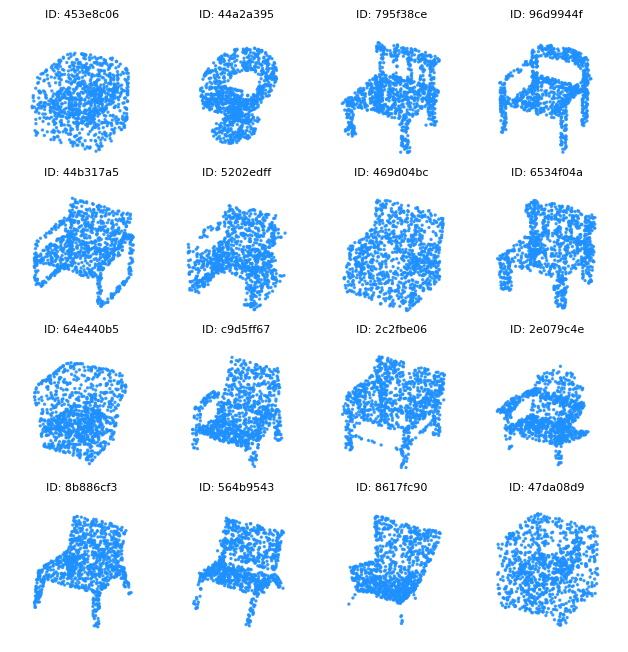

In [8]:
# raw mesh loader was very slow, precompute pointcloud as .npy instead
# precompute with ```python precompute_pointcloud.py --data-dir /ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/ --object-class 03001627 --output-dir ./sampled_poincloud/ --num-points 1024```

dataset = ShapeNetDataset(data_dir='./sampled_poincloud/', object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list)
    break

## Experiment Flow

- Define model and loss directly in this notebook for each experiment.
- Use `run_training(...)` from `experiment_runner.py` for training loop, checkpoints, metrics, tqdm, and optional wandb.

## Experiment List
- Baseline 1: Base model (no seed), Loss: Chamfer.
- Baseline 2: Base model (no seed), Loss: Chamfer + Repulsion.

## Setting up

In [10]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from model import PointCloudAE
from pytorch3d.loss import chamfer_distance
import numpy as np

from experiment_runner import ExperimentConfig, run_training

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
batch_size = 16
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

device: cuda


## Baseline 1

In [7]:
import wandb
# wandb.login(key="")

In [ ]:
# 1) Baseline experiment: Chamfer Distance only
model_cd = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_cd = torch.optim.Adam(model_cd.parameters(), lr=lr)
loss_fn_cd = lambda recon, points: chamfer_distance(
    recon.float(),
    points.float(),
    batch_reduction="mean",
    point_reduction="mean",
)[0]

cfg_cd = ExperimentConfig(
    name="baseline_cd",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="runs",
)

run_dir_cd, summary_cd = run_training(
    config=cfg_cd,
    model=model_cd,
    optimizer=optimizer_cd,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)
print("Baseline CD run dir:", run_dir_cd)
print("Baseline CD summary:", summary_cd)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pratch/.netrc.
wandb: Currently logged in as: alephnir (alephnir-vistec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


train:   0%|          | 0/382 [00:00<?, ?it/s]

val:   0%|          | 0/43 [00:00<?, ?it/s]

[baseline_cd] epoch 001/100 train 0.015647 val 0.012000 best 0.012000


train:   0%|          | 0/382 [00:00<?, ?it/s]

...

train:   0%|          | 0/382 [00:00<?, ?it/s]

val:   0%|          | 0/43 [00:00<?, ?it/s]

[baseline_cd] epoch 100/100 train 0.002819 val 0.003867 best 0.003863


epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇██
train/loss,█▅▄▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/best,█▆▄▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▄▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,73
best_val,0.00386
epoch,100
train/loss,0.00282
val/best,0.00386
val/loss,0.00387


Baseline CD run dir: runs/20260423-192828_baseline_cd
Baseline CD summary: {'best_val': 0.0038630347265753637, 'best_epoch': 73}


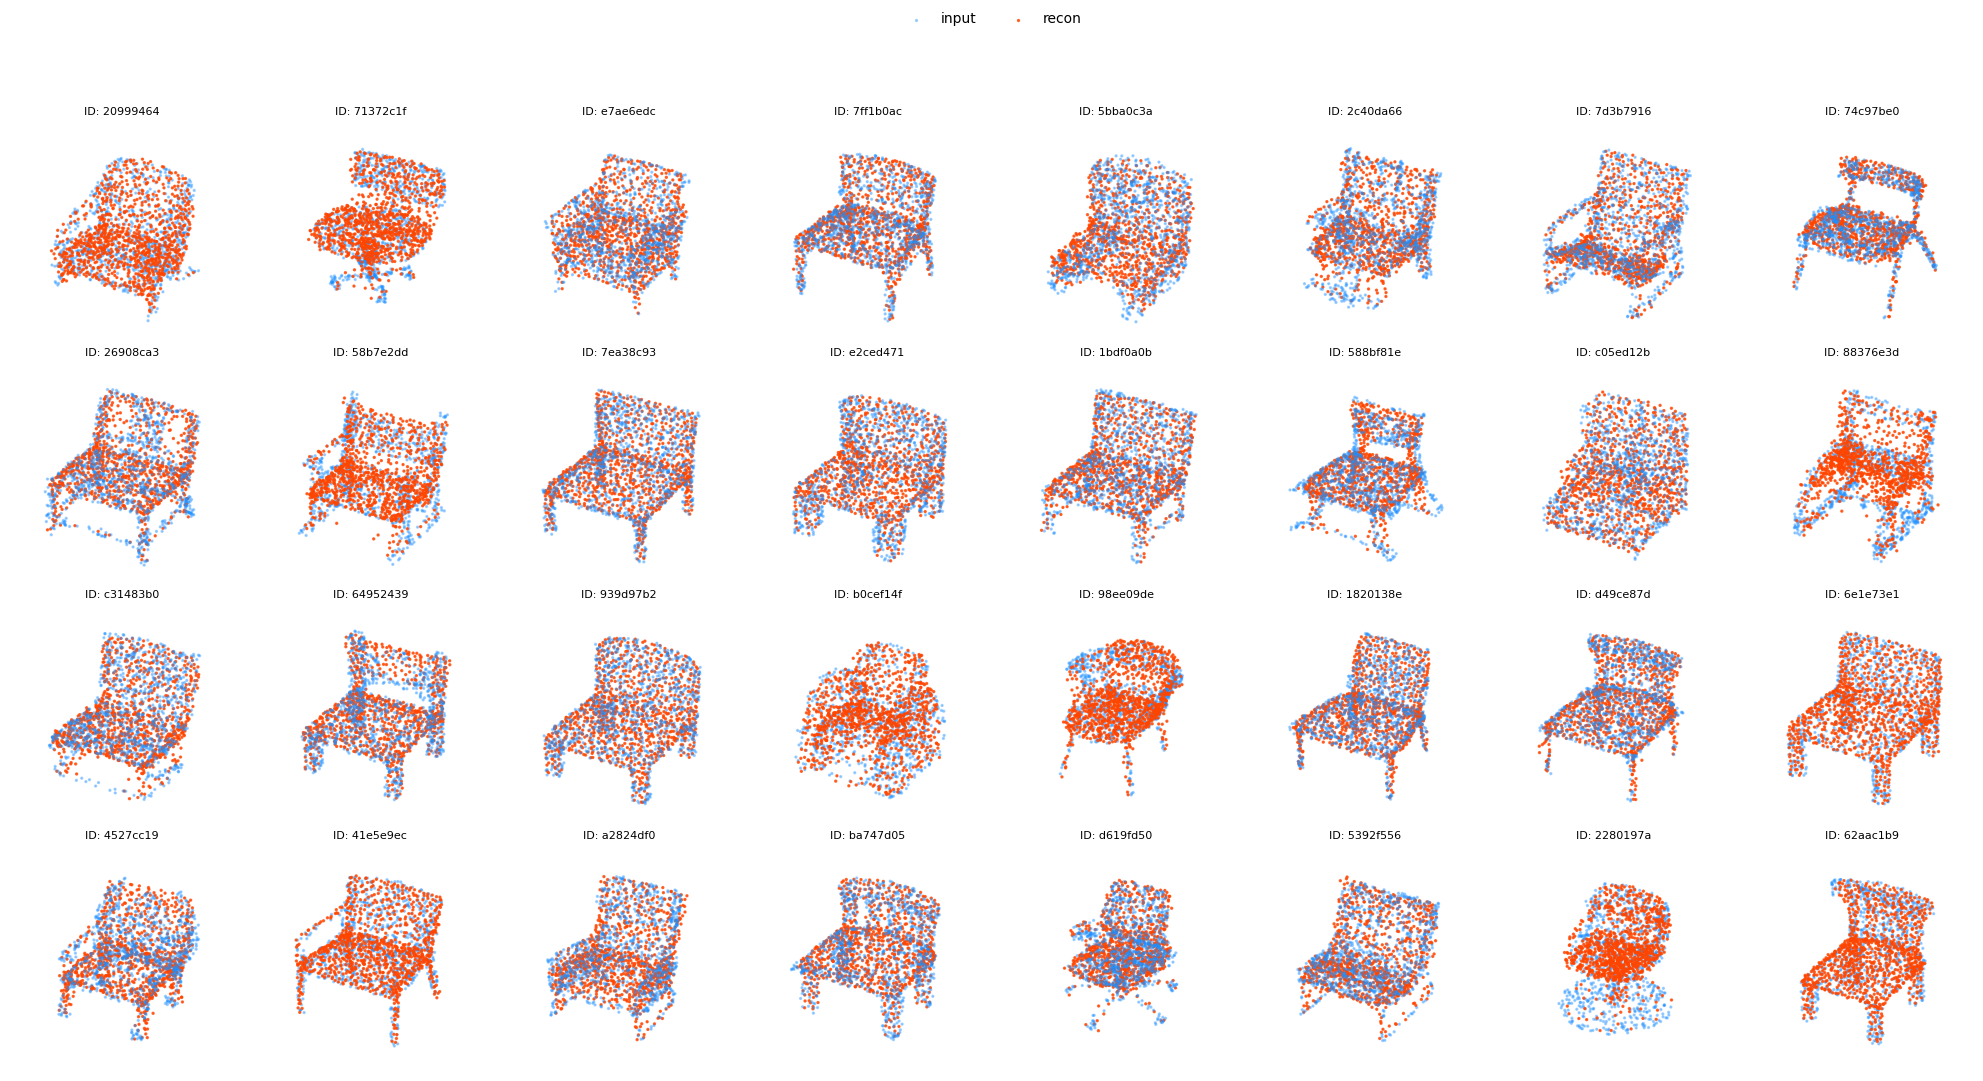

In [ ]:
# Visualize baseline reconstructions on the first two validation batches
model_cd.eval()

val_iter = iter(val_loader)
batch_1 = next(val_iter)
batch_2 = next(val_iter)

points = torch.cat([batch_1["points"], batch_2["points"]], dim=0).to(device)
obj_ids = None
if "object_id" in batch_1 and "object_id" in batch_2:
    obj_ids = list(batch_1["object_id"]) + list(batch_2["object_id"])

with torch.no_grad():
    recon, _ = model_cd(points)

points_np = points.detach().cpu().numpy()
recon_np = recon.detach().cpu().numpy()

n_show = points_np.shape[0]
n_cols = 8
n_rows = math.ceil(n_show / n_cols)

fig = plt.figure(figsize=(3.2 * n_cols, 3.0 * n_rows))
fig.patch.set_facecolor("white")

for i in range(n_show):
    ax = fig.add_subplot(n_rows, n_cols, i + 1, projection="3d")
    p_in = points_np[i]
    p_out = recon_np[i]

    # input: blue, reconstruction: orange
    ax.scatter(p_in[:, 0], p_in[:, 2], p_in[:, 1], s=2, c="dodgerblue", alpha=0.35, label="input")
    ax.scatter(p_out[:, 0], p_out[:, 2], p_out[:, 1], s=2, c="orangered", alpha=0.75, label="recon")

    if obj_ids is not None:
        ax.set_title(f"ID: {str(obj_ids[i])[:8]}", fontsize=8)

    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1])

# single legend for the whole figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
plt.subplots_adjust(wspace=0.02, hspace=0.08, top=0.90)
plt.show()

In [ ]:
# 2) Baseline skeleton: Chamfer + Repulsion
# Keep model/optimizer definitions explicit; only loss changes.
model_rep = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_rep = torch.optim.Adam(model_rep.parameters(), lr=lr)

def repulsion_loss_placeholder(_pred_points):
    # TODO: implement your repulsion loss here.
    raise NotImplementedError("Implement repulsion loss before running this experiment")

def loss_fn_cd_plus_repulsion(recon, points):
    cd = chamfer_distance(
        recon,
        points,
        batch_reduction="mean",
        point_reduction="mean",
    )[0]
    rep = repulsion_loss_placeholder(recon)
    return cd + 0.1 * rep

cfg_cd_rep = ExperimentConfig(
    name="baseline_cd_plus_repulsion_skeleton",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="runs",
)

print("Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.")
run_dir_rep, summary_rep = run_training(
    config=cfg_cd_rep,
    model=model_rep,
    optimizer=optimizer_rep,
    loss_fn=loss_fn_cd_plus_repulsion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)

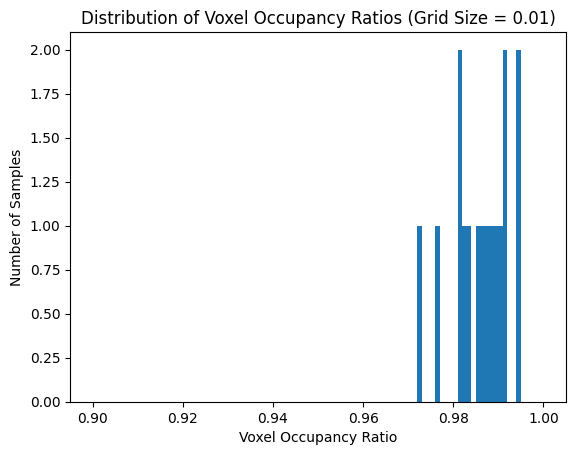

In [22]:
def check_voxel_collisions(pts, grid_size):
    grid_coord = torch.div(
        pts - pts.min(dim=0).values,
        grid_size,
        rounding_mode="trunc"
    ).int()

    unique_voxels, counts = torch.unique(grid_coord, dim=0, return_counts=True)

    num_points = pts.shape[0]
    num_unique = unique_voxels.shape[0]
    num_collided_points = counts[counts > 1].sum().item()
    num_collision_voxels = (counts > 1).sum().item()
    max_points_in_one_voxel = counts.max().item()

    # print(f"N points                : {num_points}")
    # print(f"Unique voxels           : {num_unique}")
    # print(f"Collision voxels        : {num_collision_voxels}")
    # print(f"Points in collided bins : {num_collided_points}")
    # print(f"Max points in one voxel : {max_points_in_one_voxel}")
    # print(f"Voxel occupancy ratio   : {num_unique / num_points:.4f}")

    return {
        "grid_coord": grid_coord,
        "counts": counts,
        "num_points": num_points,
        "num_unique": num_unique,
        "collision_voxels": num_collision_voxels,
        "collided_points": num_collided_points,
        "max_points_in_one_voxel": max_points_in_one_voxel,
        "occupancy_ratio": num_unique / num_points,
    }

#fetch one batch of training data, and check for collisions , for grid sizes .01 for all smaples in the batch

batch = next(iter(train_loader))
occ_ratios = []
for i in range(batch["points"].shape[0]):
    pts = batch["points"][i]
    collision_info = check_voxel_collisions(pts, grid_size=0.01)
    occ_ratios.append(collision_info["occupancy_ratio"])
    
plt.hist(occ_ratios, bins=100, range=(0.9, 1.0))
plt.xlabel("Voxel Occupancy Ratio")
plt.ylabel("Number of Samples")
plt.title("Distribution of Voxel Occupancy Ratios (Grid Size = 0.01)")
plt.show()

assert min(occ_ratios) > 0.9, "Some samples have very low occupancy ratio, consider increasing grid size or implementing a more robust repulsion loss."


In [17]:
# 3) PTv3-based skeleton: Chamfer + Repulsion 
# Keep model/optimizer definitions explicit; only loss changes.

from ptv3_based_model import PointVAE, VAEConfig

cfg = VAEConfig(hidden_dim=64, latent_dim=128, num_points=1024, variational=False, grid_size=.01)
model_ptv3 = PointVAE(cfg=cfg)
optimizer_ptv3 = torch.optim.Adam(model_ptv3.parameters(), lr=lr)

def repulsion_exp_loss(pts, h=0.04):
    # penalize very-close pairs smoothly
    B, N, _ = pts.shape
    D = torch.cdist(pts, pts)                      # (B, N, N)
    # remove diagonal by adding large value
    D = D + torch.eye(N, device=pts.device).unsqueeze(0) * 1e6
    loss = torch.exp(-(D**2) / (h**2)).sum() / (B * N * (N-1))
    return loss

def loss_fn_cd_plus_real_repulsion(recon, points):
    cd = chamfer_distance(
        recon.float(),
        points.float(),
        batch_reduction="mean",
        point_reduction="mean",
    )[0]
    rep = repulsion_exp_loss(recon)
    return cd + 0.1 * rep


cfg_cd_rep = ExperimentConfig(
    name="ptv3_cd_plus_repulsion",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=False,
    save_every=10,
    run_root="runs",
)

print("Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.")
run_dir_ptv3, summary_ptv3 = run_training(
    config=cfg_cd_rep,
    model=model_ptv3,
    optimizer=optimizer_ptv3,
    loss_fn=loss_fn_cd_plus_real_repulsion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)

Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.


train:ptv3_cd_plus_repulsion:   0%|          | 0/42500 [00:00<?, ?it/s]

[ptv3_cd_plus_repulsion] epoch 10/100 train 0.006867 val 0.007131 best 0.007131
[ptv3_cd_plus_repulsion] epoch 20/100 train 0.005509 val 0.005528 best 0.005528
[ptv3_cd_plus_repulsion] epoch 30/100 train 0.004878 val 0.005263 best 0.005228
[ptv3_cd_plus_repulsion] epoch 40/100 train 0.004516 val 0.004913 best 0.004820
[ptv3_cd_plus_repulsion] epoch 50/100 train 0.004291 val 0.004785 best 0.004615
[ptv3_cd_plus_repulsion] epoch 60/100 train 0.004103 val 0.004747 best 0.004530
[ptv3_cd_plus_repulsion] epoch 70/100 train 0.004004 val 0.004575 best 0.004440
[ptv3_cd_plus_repulsion] epoch 80/100 train 0.003951 val 0.004439 best 0.004411
[ptv3_cd_plus_repulsion] epoch 90/100 train 0.003863 val 0.004402 best 0.004359
[ptv3_cd_plus_repulsion] epoch 100/100 train 0.003792 val 0.004540 best 0.004359


epoch,▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█
train/loss,█▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/best,█▇▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,85
best_val,0.00436
epoch,100
train/loss,0.00379
val/best,0.00436
val/loss,0.00454


# Without Repulsion